In [75]:
#EDA Analysis on "Google Play Store Apps Dataset"
#Source: https://www.kaggle.com/datasets/lava18/google-play-store-apps
#Business Questions:
# Which categories have the highest-rated apps?
## Which app categories receive the most installs?
### How do free and paid apps differ in ratings and installs?



In [76]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [77]:
# Data Dictionary
import pandas as pd
data_dictionary = pd.DataFrame({
    "Column Name": [
        "App", "Category", "Rating", "Reviews", "Size",
        "Installs", "Type", "Price", "Content Rating",
        "Genres", "Last Updated", "Current Ver", "Android Ver"
    ],
    "Description": [
        "Name of the application",
        "Category of the app",
        "Average user rating (1-5)",
        "Number of user reviews",
        "Size of the app",
        "Number of installs/downloads",
        "Free or Paid app",
        "Price of the app",
        "Target audience age group",
        "Genre of the app",
        "Date when app was last updated",
        "Current version of the app",
        "Minimum Android version required"
    ]
})
display(data_dictionary)

,Column Name,Description
0,App,Name of the application
1,Category,Category of the app
2,Rating,Average user rating (1-5)
3,Reviews,Number of user reviews
4,Size,Size of the app
5,Installs,Number of installs/downloads
6,Type,Free or Paid app
7,Price,Price of the app
8,Content Rating,Target audience age group
9,Genres,Genre of the app


In [78]:
# Load Dataset
df = pd.read_csv("googleplaystore.csv")
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [79]:
# First 5 rows of dataset
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [80]:
#Basics
print(df.info())

print("\nShape:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None

Shape:
(10841, 13)


In [81]:
# Missing Values
print(df.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [109]:
# Handling Missing Values
## Rating Column
df['Rating'].fillna(df['Rating'].median())

## Type Column
df['Type'].fillna(df['Type'].mode()[0])

## Content Rating
df['Content Rating'].fillna(df['Content Rating'].mode()[0])

## Current Version
df['Current Ver'].fillna(df['Current Ver'].mode()[0])

## Android Version
df['Android Ver'].fillna(df['Android Ver'].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [83]:
# Duplicate Records
print(df.duplicated().sum())

483


In [84]:
# Duplicates Removal
df.drop_duplicates(inplace=True)

print(df.shape)

(10358, 13)


In [85]:
# Data Type Conversion
# Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')


In [86]:
# Installs
df['Installs'] = df['Installs'].str.replace('+','',regex=False)
df['Installs'] = df['Installs'].str.replace(',','',regex=False)
df['Installs'] = pd.to_numeric(df['Installs'],errors='coerce')

In [87]:
# Price
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$','',regex=False)
df['Price'] = pd.to_numeric(df['Price'],errors='coerce')

In [88]:
# Size Conversion
def convert_size(size):

    if isinstance(size,str):

        if 'M' in size:
            return float(size.replace('M',''))

        elif 'k' in size:
            return float(size.replace('k',''))/1024

        else:
            return np.nan

    return size

df['Size'] = df['Size'].apply(convert_size)

In [112]:
# Final Check
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   App                    10358 non-null  object 
 1   Category               10358 non-null  object 
 2   Rating                 8893 non-null   float64
 3   Reviews                10357 non-null  float64
 4   Size                   8831 non-null   float64
 5   Installs               10357 non-null  float64
 6   Type                   10357 non-null  object 
 7   Price                  10357 non-null  float64
 8   Content Rating         10357 non-null  object 
 9   Genres                 10358 non-null  object 
 10  Last Updated           10358 non-null  object 
 11  Current Ver            10350 non-null  object 
 12  Android Ver            10355 non-null  object 
 13  Popularity_Score       8892 non-null   float64
 14  ContentRating_Encoded  10357 non-null  float64
 15  Type_La

In [90]:
# Outlier Analysis
# Numerical Columns
num_cols = ['Rating',
            'Reviews',
            'Size',
            'Installs',
            'Price']

In [91]:
# Skewness Metrics
for col in num_cols:
    print(col)
    print("Skewness:",df[col].skew())
    print("-"*30)

Rating
Skewness: 0.6418611034487824
------------------------------
Reviews
Skewness: 17.46733529306297
------------------------------
Size
Skewness: 1.569785090297752
------------------------------
Installs
Skewness: 10.126705367146252
------------------------------
Price
Skewness: 23.324380787733904
------------------------------


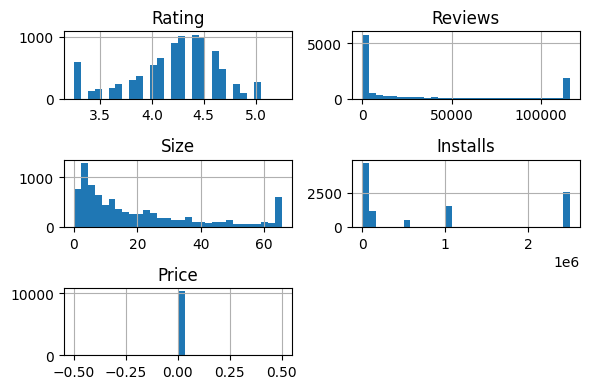

In [111]:
# Histogram
df[num_cols].hist(figsize=(6,4), bins=30)
plt.tight_layout()
plt.show()

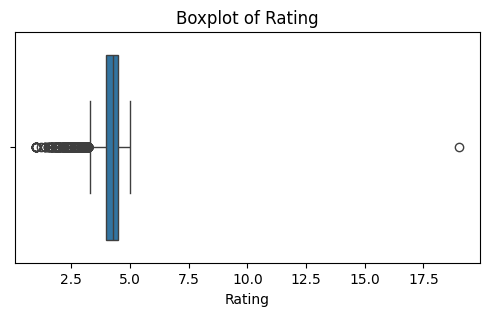

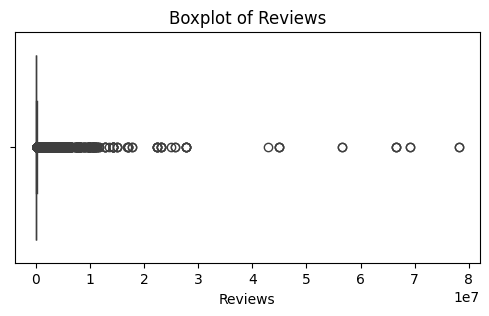

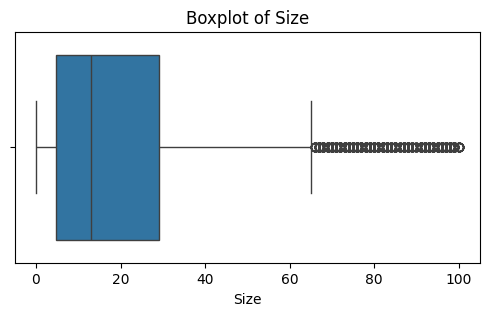

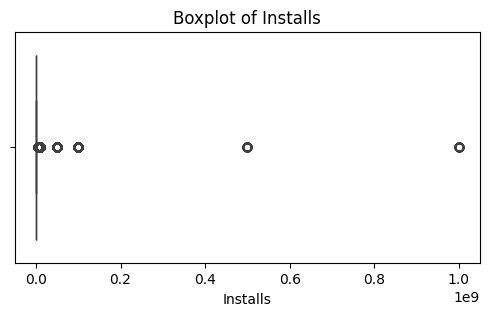

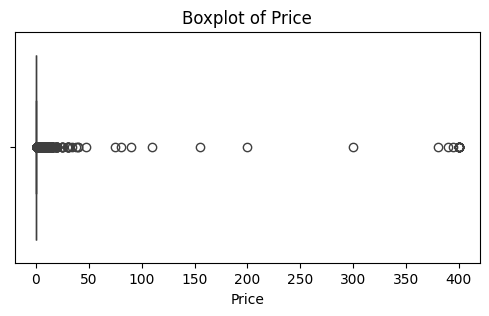

In [93]:
# Box Plots
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [94]:
# IQR Outliers Detection
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_range = Q1 - 1.5*IQR
  upper_range = Q3 + 1.5*IQR
  outliers = df[ (df[col] < lower_range) | (df[col] > upper_range)]
  print(f"{col}: {len(outliers)} outliers")

Rating: 496 outliers
Reviews: 1870 outliers
Size: 582 outliers
Installs: 2566 outliers
Price: 765 outliers


In [95]:
# Applying Winsorization(Capping)
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_range = Q1 - 1.5*IQR
  upper_range = Q3 + 1.5*IQR
  df[col] = np.where(df[col] > upper_range, upper_range, df[col])
  df[col] = np.where(df[col] < lower_range, lower_range, df[col])


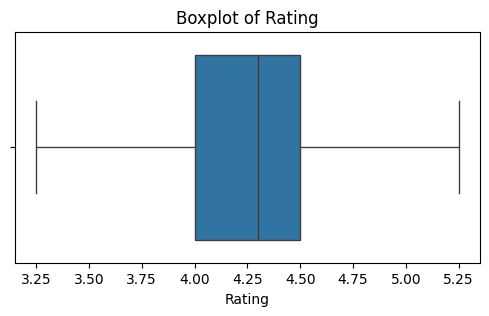

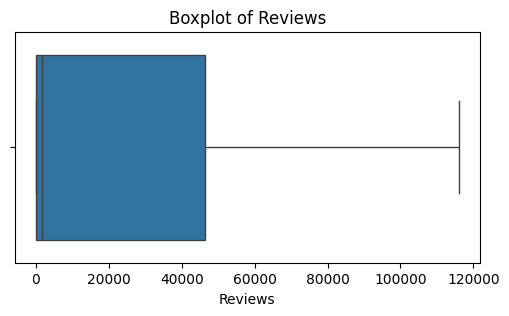

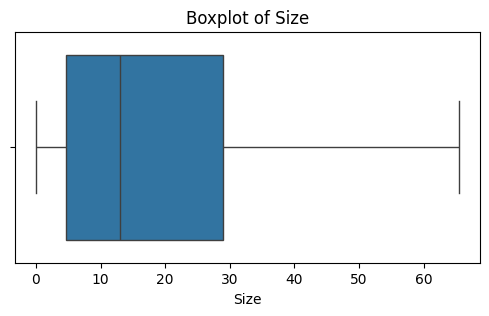

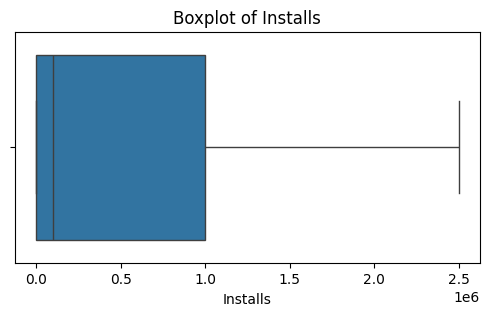

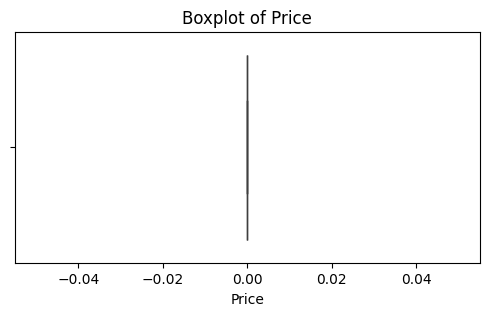

In [96]:
# Final Check of Boxplots after capping.
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [97]:
# Report for IQR Outliers
# Outliers were detected using the IQR method. Extreme values lying beyond 1.5 × IQR from the first
# and third quartiles were identified. Instead of removing records, Winsorization (capping) was applied
# to reduce the influence of outliers while preserving the dataset size.

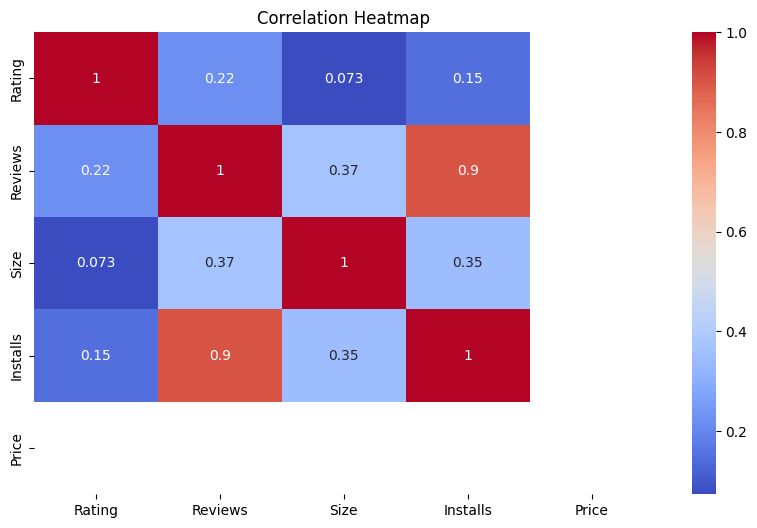

In [98]:
# Bivariate & Multivariate Exploration
## Correlation Heatmap
plt.figure(figsize=(10,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [99]:
# Relationships observed:
# Strong Positive Ones: Reviews - Installs, Ratings - Reviews
# Negative Ones: Paid apps generally receive fewer installs.

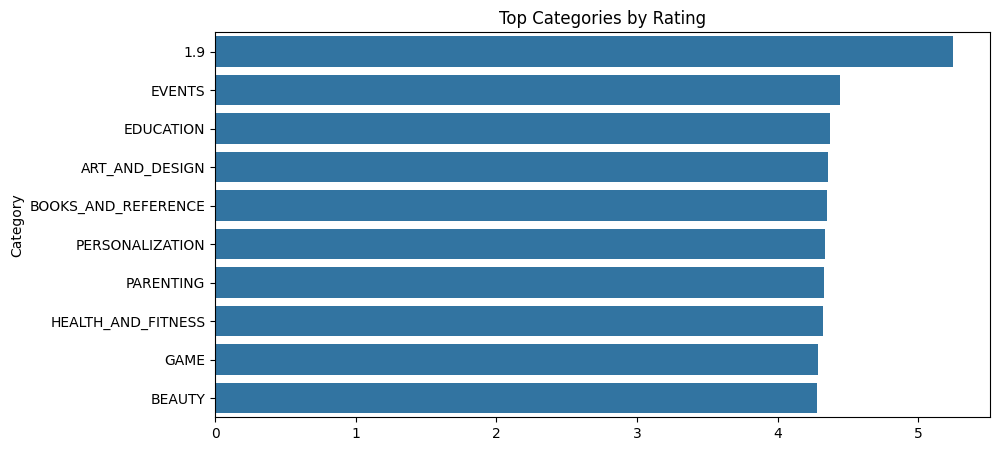

In [100]:
# Top Categories by Average Rating (Bar Plot):
top_rating = df.groupby('Category')['Rating'].mean()
top_rating = top_rating.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_rating.values, y=top_rating.index)
plt.title("Top Categories by Rating")
plt.show()

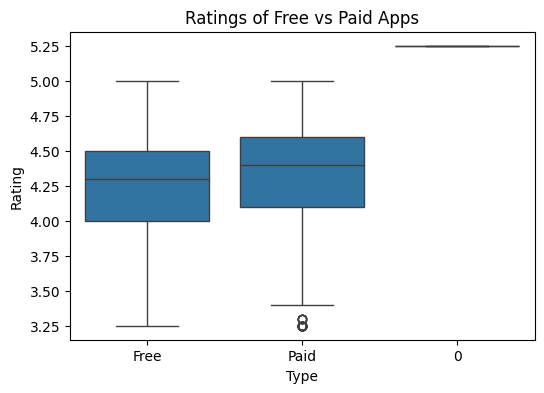

In [101]:
# Free Apps vs Paid Apps (Box Plot):
plt.figure(figsize=(6,4))
sns.boxplot(x='Type', y='Rating', data = df)
plt.title("Ratings of Free vs Paid Apps")
plt.show()


In [102]:
# Correlation does not imply direct causation. For exampole, Apps with many installs usually have many reviews.
# However, Installs may cause reviews, good app quality may cause both, marketing campaigns may influence both.
# Hence correlation does not imply direct causation.

In [103]:
# Feature Engineering and Encoding Preparation
# Feature 1 Creation:
## App Popularity Score
df['Popularity_Score'] = (df['Rating'] * np.log1p(df['Installs']))

In [104]:
# Feature Viewing, that has been created above.
df[['App', 'Popularity_Score']].head()

,App,Popularity_Score
0,Photo Editor & Candy Camera & Grid & ScrapBook,37.762806
1,Coloring book moana,51.177225
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",69.236647
3,Sketch - Draw & Paint,66.290407
4,Pixel Draw - Number Art Coloring Book,49.505622


In [105]:
# Ordinal Columns (Ranked)
content_rating_order = {
    'Everyone': 1,
    'Everyone 10+': 2,
    'Teen': 3,
    'Mature 17+': 4,
    'Adults only 18+': 5,
    'Unrated': 0
}
df['ContentRating_Encoded'] = df['Content Rating'].map(content_rating_order)

In [106]:
# Nominal Columns (Unranked)
nominal_cols = [
    'Category',
    'Genres',
    'Type'
]

In [107]:
# Label Encoding (For Ranked Categories)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Type_Label'] = le.fit_transform(df['Type'])
print(df[['Type','Type_Label']].head())

   Type  Type_Label
0  Free           1
1  Free           1
2  Free           1
3  Free           1
4  Free           1


In [108]:
# One Hot Encoding (For Unranked Categories)
df_encoded = pd.get_dummies(df, columns=['Category','Genres'], drop_first=True)
print(df_encoded.shape)

(10358, 166)
